In [4]:
import yfinance as yf
import matplotlib.pyplot as plt

In [5]:
data = yf.download("JPM", start="2021-01-01", end="2025-01-01")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             JPM         JPM         JPM         JPM       JPM
Date                                                                
2021-01-04  109.000534  110.723827  108.056616  110.412074  16819900
2021-01-05  109.593636  110.160576  107.953870  109.017971  13731200
2021-01-06  114.739670  115.803771  111.538642  113.283075  24909100
2021-01-07  118.507652  120.531194  117.679052  118.350660  21940400
2021-01-08  118.638496  118.926328  116.981283  118.594883  12035100


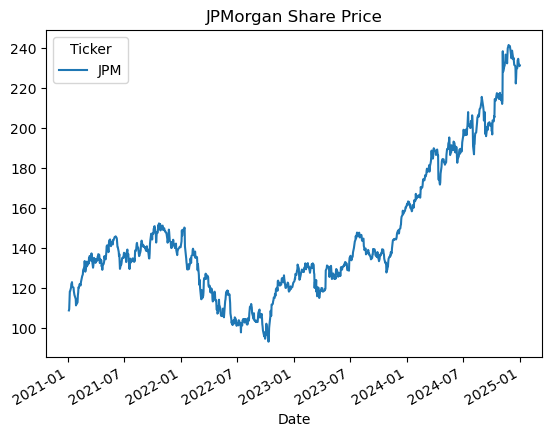

In [6]:
data["Close"].plot()
plt.title("JPMorgan Share Price")
plt.show()

In [7]:
returns = data["Close"].pct_change()
print(returns.head())

Ticker           JPM
Date                
2021-01-04       NaN
2021-01-05  0.005441
2021-01-06  0.046956
2021-01-07  0.032839
2021-01-08  0.001104


In [8]:
average_return = returns.mean()
print(average_return)

Ticker
JPM    0.000865
dtype: float64


In [9]:
annual_return = average_return * 252
print(annual_return)

Ticker
JPM    0.218084
dtype: float64


In [10]:
daily_volatility = returns.std()
print(daily_volatility)

Ticker
JPM    0.015206
dtype: float64


In [11]:
annual_volatility = daily_volatility * (252**0.5)
print(annual_volatility)

Ticker
JPM    0.24139
dtype: float64


In [12]:
sharpe_ratio = annual_return/annual_volatility
print(sharpe_ratio)

Ticker
JPM    0.903452
dtype: float64


In [13]:
companies = ["PHG", "WCC", "MCK"]
dataset = yf.download(companies, start="2016-01-01", end="2026-01-01")
close_prices = dataset["Close"]
print(close_prices.head())

[*********************100%***********************]  3 of 3 completed

Ticker             MCK        PHG        WCC
Date                                        
2016-01-04  179.737244  19.660347  42.718040
2016-01-05  180.503601  19.448099  42.504890
2016-01-06  178.287674  19.196552  42.010765
2016-01-07  173.403519  19.062912  40.838413
2016-01-08  168.399185  18.897833  39.501358


In [14]:
returns = close_prices.pct_change()
print(returns.head())

Ticker           MCK       PHG       WCC
Date                                    
2016-01-04       NaN       NaN       NaN
2016-01-05  0.004264 -0.010796 -0.004990
2016-01-06 -0.012276 -0.012934 -0.011625
2016-01-07 -0.027395 -0.006962 -0.027906
2016-01-08 -0.028859 -0.008660 -0.032740


In [15]:
correlation = returns.corr()
print(correlation)

Ticker       MCK       PHG       WCC
Ticker                              
MCK     1.000000  0.207707  0.203946
PHG     0.207707  1.000000  0.324109
WCC     0.203946  0.324109  1.000000


In [16]:
average_return = returns.mean()
print(average_return)

Ticker
MCK    0.000769
PHG    0.000311
WCC    0.001097
dtype: float64


In [17]:
annual_return = average_return * 252
print(annual_return)

Ticker
MCK    0.193792
PHG    0.078426
WCC    0.276474
dtype: float64


In [19]:
daily_volatility = returns.std()
print(daily_volatility)

Ticker
MCK    0.018095
PHG    0.019965
WCC    0.028061
dtype: float64


In [20]:
annual_volatility = daily_volatility * (252**0.5)
print(annual_volatility)

Ticker
MCK    0.287244
PHG    0.316939
WCC    0.445457
dtype: float64


In [21]:
sharpe_ratios = annual_return/annual_volatility
print(sharpe_ratios)

Ticker
MCK    0.674660
PHG    0.247449
WCC    0.620652
dtype: float64


In [22]:
import numpy as np
weights = np.array([0.4,0.25,0.35])

portfolio_return = np.sum(weights*annual_return)
print(portfolio_return)

0.19388918958606183


In [23]:
cov_matrix = returns.cov() * 252
portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
print(portfolio_volatility)

0.2507669347980292


In [24]:
portfolio_sharpe = portfolio_return/portfolio_volatility
print(portfolio_sharpe)

0.7731848289417526


In [25]:
risk_free_data = yf.download("^IRX",start="2016-01-01",end="2026-01-01")
print(risk_free_data["Close"].head())

[*********************100%***********************]  1 of 1 completed

Ticker       ^IRX
Date             
2016-01-04  0.155
2016-01-05  0.205
2016-01-06  0.205
2016-01-07  0.190
2016-01-08  0.190


In [27]:
print(risk_free_data["Close"].describe())

Ticker         ^IRX
count   2513.000000
mean       2.157118
std        1.886206
min       -0.105000
25%        0.295000
50%        1.713000
75%        4.193000
max        5.348000


In [28]:
risk_free_rate = risk_free_data["Close"].mean()/100
print(risk_free_rate)

Ticker
^IRX    0.021571
dtype: float64


In [29]:
portfolio_return = annual_return.mean()
sharpe_ratio = (portfolio_return - risk_free_rate)/portfolio_volatility
print(sharpe_ratio)

Ticker
^IRX    0.643331
dtype: float64


In [30]:
portfolio_daily_returns = (returns * weights).sum(axis=1)
print(portfolio_daily_returns.head())

Date
2016-01-04    0.000000
2016-01-05   -0.002740
2016-01-06   -0.012213
2016-01-07   -0.022465
2016-01-08   -0.025168
dtype: float64


In [31]:
average_return = portfolio_daily_returns.mean()
annual_return = average_return * 252
print(annual_return)

0.19381206580341026


In [ ]:
portfolio_volatility = portfolio_daily_returns.std() * (252 ** 0.5)
print(portfolio_volatility)

In [ ]:
sharpe_ratio = (annual_return-risk_free_rate)/portfolio_volatility
print(sharpe_ratio)

In [ ]:
portfolio_value = (1 + portfolio_daily_returns).cumprod()
running_peak = portfolio_value.cummax()
drawdown = (portfolio_value - running_peak)/running_peak
max_drawdown = drawdown.min()
print(max_drawdown)

In [ ]:
worst_date = drawdown.idxmin()
print(worst_date)

In [ ]:
peak_before_crash = running_peak.loc[worst_date]
recovery_date = portfolio_value.loc[worst_date:][portfolio_value.loc[worst_date:] >= peak_before_crash].index[0]
print(recovery_date)

In [ ]:
final_value = portfolio_value.iloc[-1]
print(final_value)

In [ ]:
years = 10
cagr = (final_value ** (1/years)) - 1
print(cagr)

In [59]:
benchmark = yf.download("^GSPC", start="2016-01-01", end="2026-01-01")
print(benchmark["Close"].head())

[*********************100%***********************]  1 of 1 completed

Ticker            ^GSPC
Date                   
2016-01-04  2012.660034
2016-01-05  2016.709961
2016-01-06  1990.260010
2016-01-07  1943.089966
2016-01-08  1922.030029


In [61]:
benchmark_returns = benchmark["Close"].squeeze().pct_change()
print(benchmark_returns.head())

Date
2016-01-04         NaN
2016-01-05    0.002012
2016-01-06   -0.013115
2016-01-07   -0.023700
2016-01-08   -0.010838
Name: ^GSPC, dtype: float64


In [63]:
benchmark_annual_return = benchmark_returns.mean() * 252
print(benchmark_annual_return)

0.1392680581003566


In [65]:
benchmark_volatility = benchmark_returns.std() * (252**0.5)
print(benchmark_volatility)

0.18128553826600804


In [67]:
risk_free_rate = risk_free_rate.item()
benchmark_sharpe = (benchmark_annual_return - risk_free_rate)/benchmark_volatility
print(benchmark_sharpe)

0.6492348003007927


In [69]:
benchmark_prices = benchmark["Close"].squeeze()
benchmark_returns = benchmark_prices.pct_change()
benchmark_value = (1+benchmark_returns).cumprod()
benchmark_peak = benchmark_value.cummax()
benchmark_drawdown = (benchmark_value - benchmark_peak)/benchmark_peak
benchmark_max_drawdown = benchmark_drawdown.min()
print(benchmark_max_drawdown)

-0.3392496000265331


In [71]:
benchmark_final_value = benchmark_value.iloc[-1]
print(benchmark_final_value)

3.401220217894407


In [75]:
years=10
benchmark_cagr = benchmark_final_value ** (1/years) - 1
print(benchmark_cagr)

0.13022126748060692


In [77]:

beta = portfolio_daily_returns.cov(benchmark_returns) / benchmark_returns.var()
print(beta)

1.0116352199548315


In [79]:
import pandas as pd
aligned = pd.concat([portfolio_daily_returns,benchmark_returns],axis=1).dropna()
aligned.columns = ["portfolio", "market"]
print(aligned.head())

            portfolio    market
Date                           
2016-01-05  -0.002740  0.002012
2016-01-06  -0.012213 -0.013115
2016-01-07  -0.022465 -0.023700
2016-01-08  -0.025168 -0.010838
2016-01-11  -0.045679  0.000853


In [81]:
beta = aligned["portfolio"].cov(aligned["market"]) / aligned["market"].var()
print(beta)

1.0116352199548315


In [83]:
alpha = annual_return - (
    risk_free_rate + beta * (benchmark_annual_return - risk_free_rate)
)

print(alpha)

0.0531745786135388


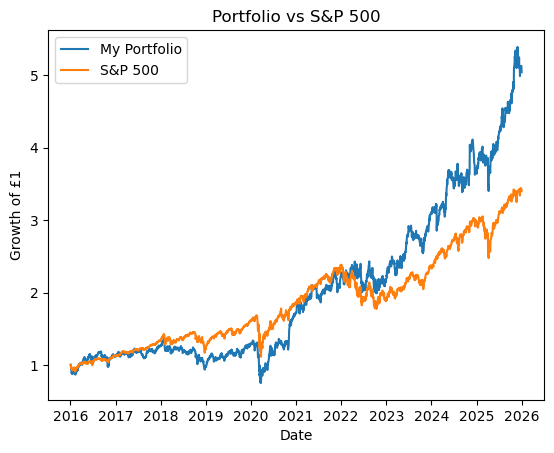

In [85]:
portfolio_growth = (1 + portfolio_daily_returns).cumprod()
market_growth = (1 + benchmark_returns).cumprod()

plt.plot(portfolio_growth, label="My Portfolio")
plt.plot(market_growth, label="S&P 500")

plt.title("Portfolio vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.show()

In [87]:
portfolio_2023 = portfolio_growth.loc["2023-01-01":]
market_2023 = market_growth.loc["2023-01-01":]

In [89]:
print(portfolio_2023.iloc[0])
print(portfolio_2023.iloc[-1])

print(market_2023.iloc[0])
print(market_2023.iloc[-1])

2.199073387240091
5.043692314837378
1.9000426438818538
3.401220217894407
